# Занятие 6: Классификация изображений. Сверточные нейросети (CNN)

## 1. Зачем нужны сверточные сети

Раньше мы применяли полносвязные сети **(Dense)** для задач вроде MNIST.
Они неплохо справлялись, но им приходилось **запоминать каждый пиксель отдельно.**
Это плохо работает с более сложными изображениями — где важна не отдельная точка, а **формы и контуры.**

**Проблема Dense-сетей:**

* Слишком много параметров (каждый пиксель — отдельный вес).

* Не учитывают пространственные связи (квадрат 3×3 = просто 9 отдельных точек).

**Решение — сверточные сети (CNN):**
они "сканируют" изображение маленьким окошком (фильтром), вычленяя важные признаки — контуры, цвета, формы.

## 2. Что делает сверточная сеть

Сверточная сеть — это модель, которая умеет **автоматически извлекать признаки из изображения**.
Если в обычной нейросети мы передаем “сырые” пиксели, то CNN сама **находит важные фрагменты** — углы, линии, текстуры, объекты.

**Dense-сеть:**

* Видит картинку как набор чисел.
* Не понимает, что рядом пиксель 50 и 51 — это одна линия.

**CNN:**

* Смотрит на локальные участки (например, квадратик 3×3).
* Запоминает, какие формы часто встречаются (горизонт, диагональ, глаз, ухо и т.д.).

## 3. Основная идея свёртки (Convolution)

Свёртка — это операция, при которой **маленький фильтр (ядро)** скользит по изображению и вычисляет взвешенную сумму соседних пикселей.

* **Фильтр (kernel)** — это небольшая матрица (например, 3×3).
* Каждый элемент фильтра — “вес”, который определяет, какие паттерны нужно выделить.
* После прохождения по всему изображению получается новая “карта признаков” (feature map).

Пример:

* Фильтр [-1, 0, 1] выделяет вертикальные линии.
* Фильтр [-1, -1, -1; 0, 0, 0; 1, 1, 1] — горизонтальные.

### Свёртка изображения:

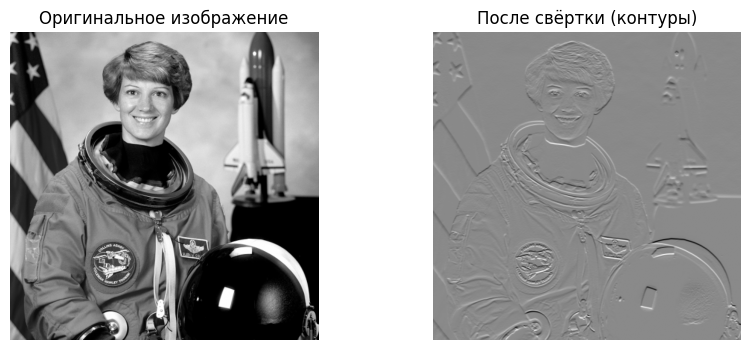

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage import data, color

image = color.rgb2gray(data.astronaut())
sobel_filter = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])
filtered = ndimage.convolve(image, sobel_filter)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.title("Оригинальное изображение")
plt.imshow(image, cmap='gray')
plt.axis('off')

plt.subplot(1,2,2)
plt.title("После свёртки (контуры)")
plt.imshow(filtered, cmap='gray')
plt.axis('off')
plt.show()

*Так CNN видит границы, текстуры и формы на ранних слоях.*

## 4. Основные блоки CNN

| Блок             | Что делает                              | Аналогия                                     |
| ---------------- | --------------------------------------- | -------------------------------------------- |
| **Conv2D**       | Свёртка изображения фильтрами           | "Сканирует" фрагменты картинки               |
| **ReLU**         | Добавляет нелинейность                  | "Подсвечивает" активные признаки             |
| **MaxPooling2D** | Уменьшает размерность, выделяет главное | "Сжимает" изображение, убирая лишние детали  |
| **Flatten**      | Превращает 2D-признаки в вектор         | "Разворачивает" в 1D перед финальными слоями |
| **Dense**        | Классификатор                           | "Решает", что на картинке                    |
| **Softmax**      | Переводит выходы в вероятности          | "Сколько процентов уверенности"              |

**Типовая структура CNN:**

```
Вход (32x32x3)
↓
Conv2D (фильтры 3x3) → ReLU
↓
MaxPooling (2x2)
↓
Conv2D → ReLU → MaxPooling
↓
Flatten
↓
Dense → Softmax
```

### Демонстрация MaxPooling

2025-11-10 17:05:28.454308: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 17:05:28.466133: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-10 17:05:28.608736: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-10 17:05:28.642332: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762783528.724621 1455596 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762783528.74

Исходное изображение:
 [[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]

После MaxPooling:
 [[ 6.  8.]
 [14. 16.]]


2025-11-10 17:05:31.964069: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


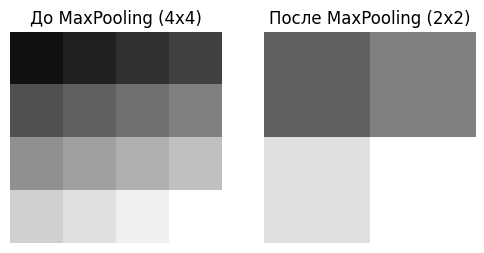

In [2]:
import tensorflow as tf

# Создаём искусственное изображение 4x4
image = tf.constant([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 10, 11, 12],
    [13, 14, 15, 16]
], dtype=tf.float32)
image = tf.reshape(image, (1, 4, 4, 1))

# Применяем MaxPooling 2x2
pooled = tf.nn.max_pool2d(image, ksize=2, strides=2, padding='VALID')

# Визуализируем
print("Исходное изображение:\n", tf.squeeze(image).numpy())
print("\nПосле MaxPooling:\n", tf.squeeze(pooled).numpy())

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(tf.squeeze(image), cmap='gray', vmin=0, vmax=16)
plt.title("До MaxPooling (4x4)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(tf.squeeze(pooled), cmap='gray', vmin=0, vmax=16)
plt.title("После MaxPooling (2x2)")
plt.axis('off')
plt.show()

*Сеть ‘сжимает’ изображение, сохраняя самые важные сигналы — так она учится быть устойчивой к шуму.*

### Сравнение количества параметров: Dense vs CNN

In [3]:
from tensorflow.keras import Sequential, layers

# Полносвязная модель (Dense)
dense_model = Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# CNN модель
cnn_model = Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Сравниваем количество параметров
dense_model.summary()
cnn_model.summary()

/usr/lib/python3/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/lib/python3/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,634 (1.51 MB)

 Trainable params: 394,634 (1.51 MB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Как CNN видит изображение

CNN видит изображение **через уровни абстракции**:

1. **Ранние слои** — простые формы (линии, контуры).
2. **Средние** — части объектов (глаза, уши, крылья).
3. **Поздние** — целые объекты (кошка, собака, машина).

Это и есть “глубокое обучение”: каждый слой обучается извлекать всё более сложные признаки.

### Фильтр Sobel

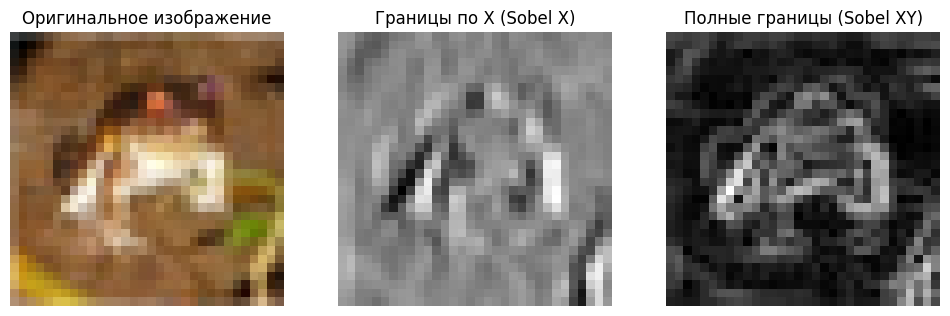

In [4]:
from tensorflow.keras.datasets import cifar10

# Загружаем данные
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
image = X_train[0]
image_gray = np.mean(image, axis=-1) / 255.0  # перевод в серый

# Фильтры Собеля
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

# Применяем фильтры
edges_x = ndimage.convolve(image_gray, sobel_x)
edges_y = ndimage.convolve(image_gray, sobel_y)
edges = np.hypot(edges_x, edges_y)  # объединяем по направлениям

# Визуализация
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(image.astype('uint8'))
plt.title("Оригинальное изображение")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(edges_x, cmap='gray')
plt.title("Границы по X (Sobel X)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(edges, cmap='gray')
plt.title("Полные границы (Sobel XY)")
plt.axis('off')
plt.show()

*Сеть делает то же самое — только фильтры она подбирает сама. В первых слоях CNN действительно появляются похожие паттерны: вертикали, горизонтали, углы.*

## 6. Практика: классификация CIFAR-10

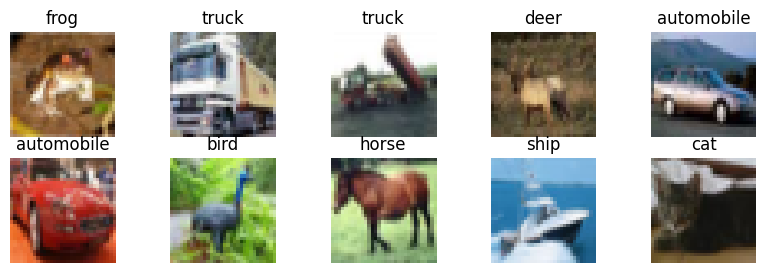

In [5]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np

# загрузка данных
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# нормализация
X_train, X_test = X_train / 255.0, X_test / 255.0
y_train, y_test = to_categorical(y_train), to_categorical(y_test)

# просмотр примеров
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
plt.figure(figsize=(10,3))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[np.argmax(y_train[i])])
    plt.axis('off')
plt.show()


### Построение модели CNN

In [6]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

### Архитектура сверточной нейросети

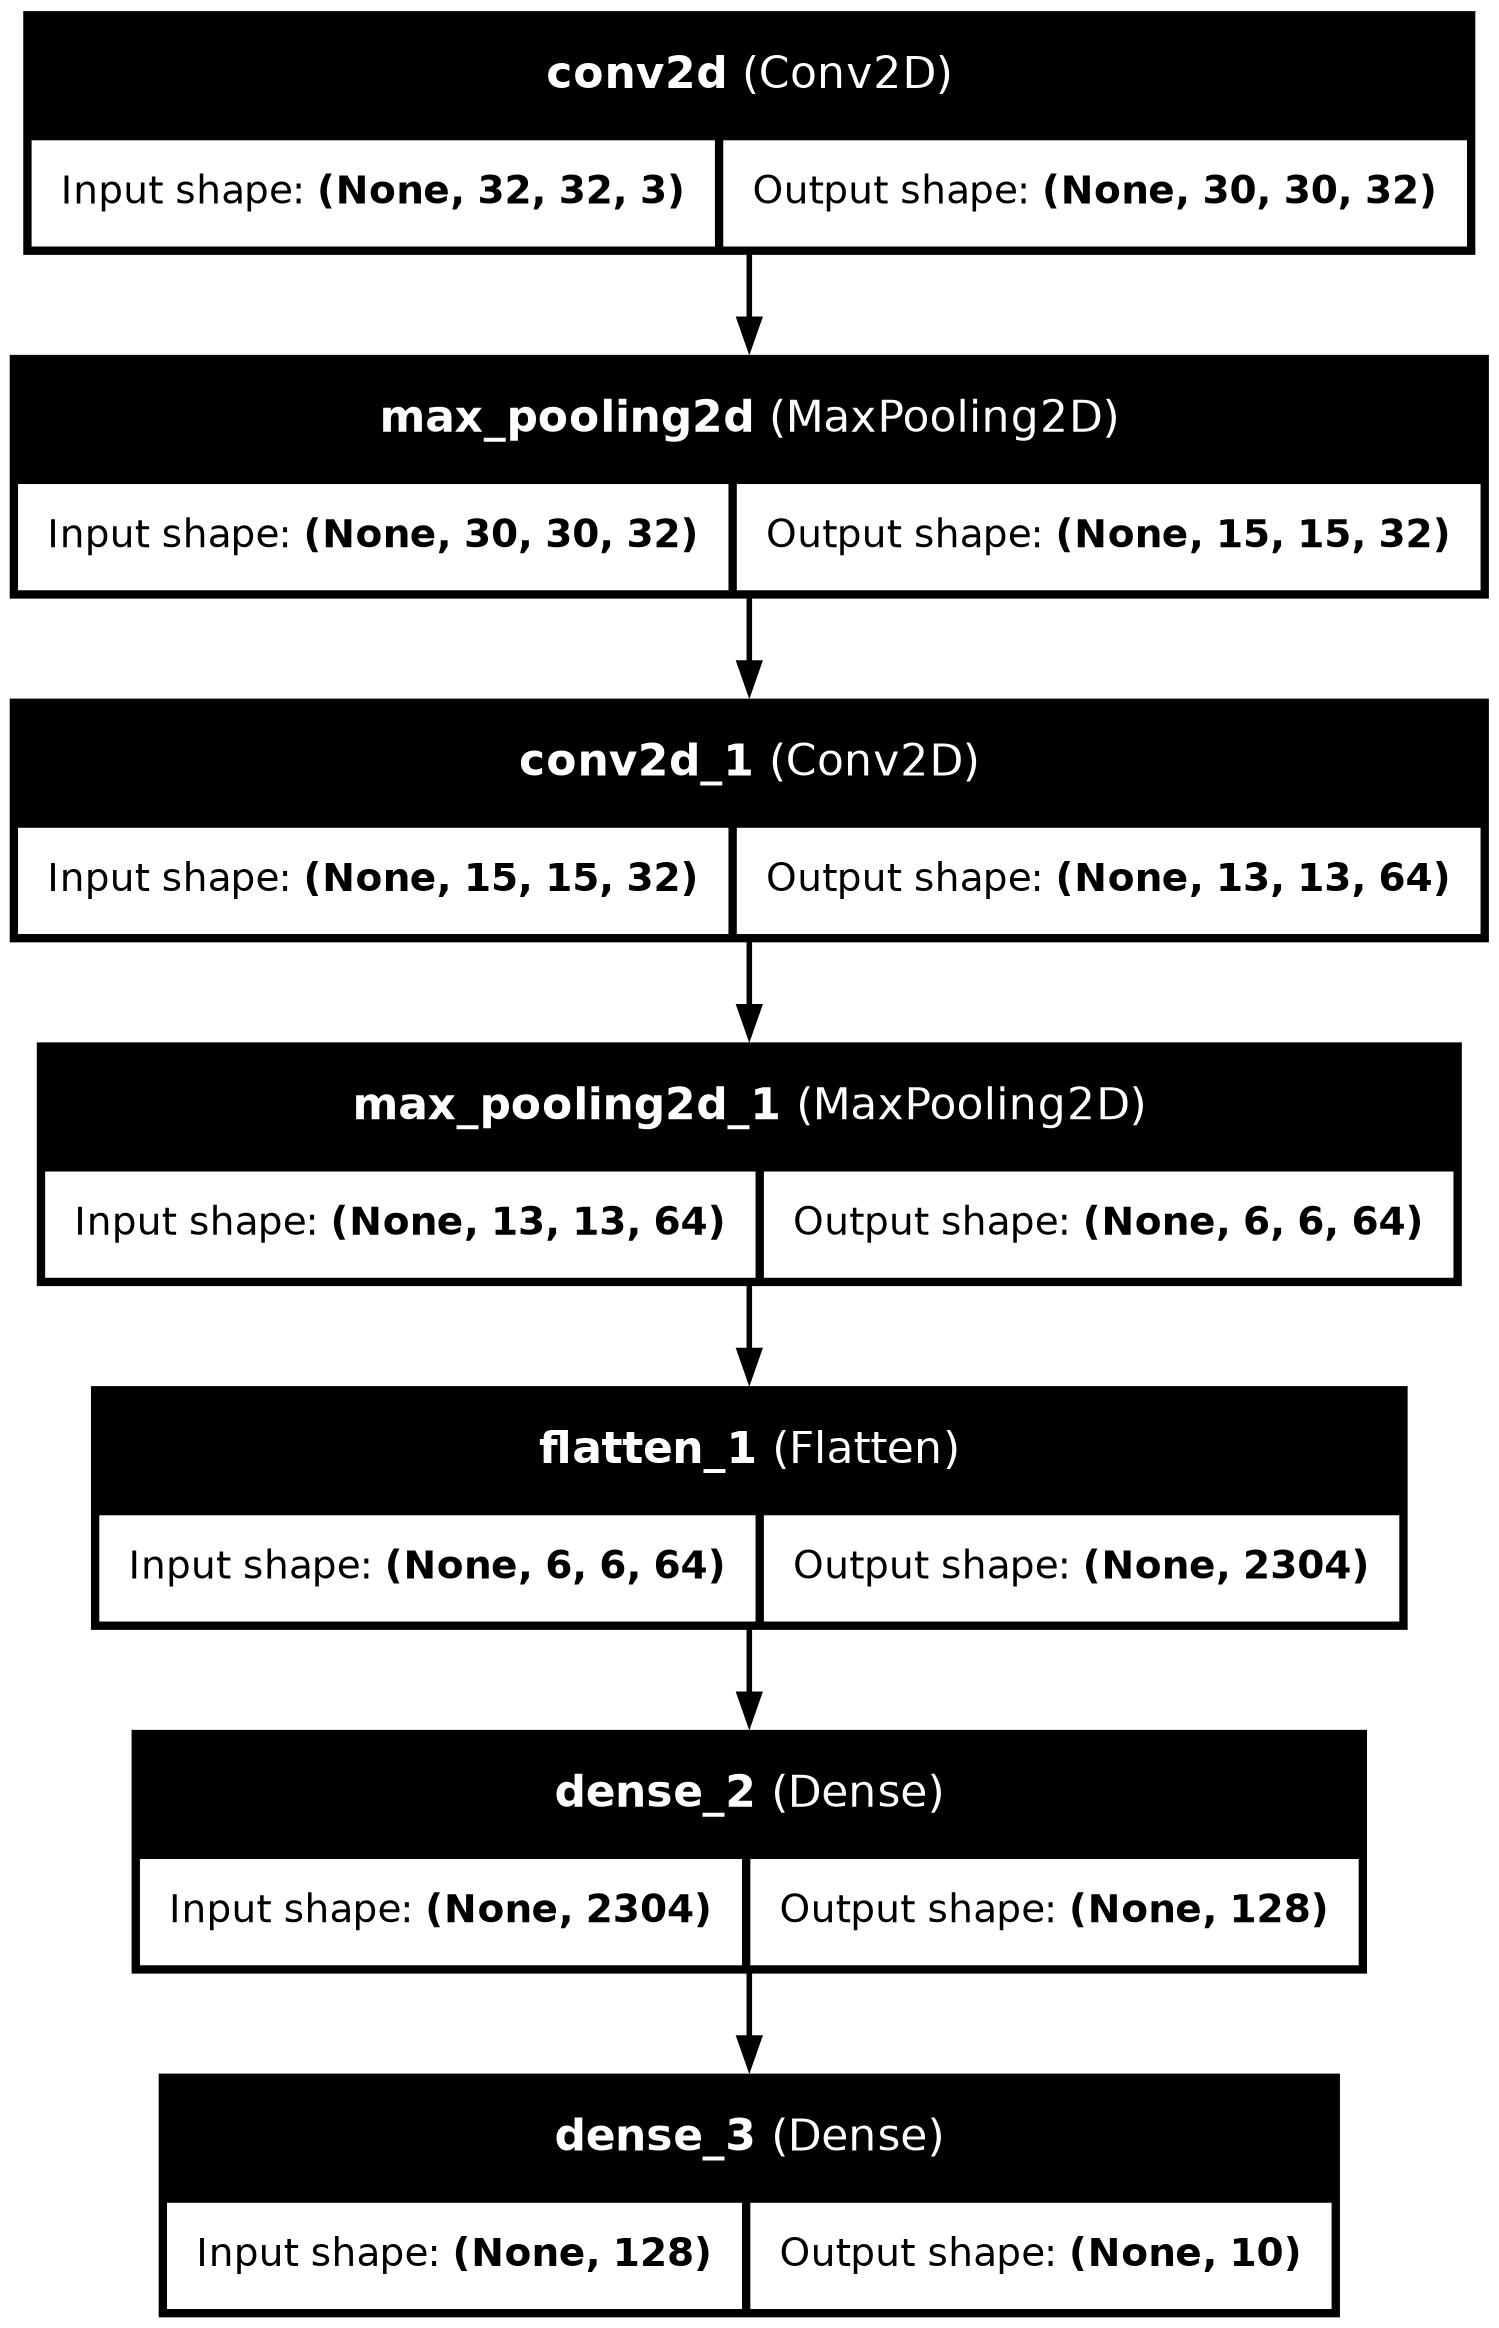

In [7]:
import importlib.util
from IPython.display import Image, SVG
from tensorflow.keras.utils import plot_model, model_to_dot

try:
    if importlib.util.find_spec("graphviz") is not None:
        plot_model(cnn_model, show_shapes=True, show_layer_names=True, to_file="cnn_architecture.png")
        display(Image("cnn_architecture.png"))
    else:
        dot = model_to_dot(cnn_model, show_shapes=True, show_layer_names=True)
        display(SVG(dot.create(prog='dot', format='svg')))
except Exception as e:
    print("Не удалось отрисовать граф. Показываю структуру текстом.\n")
    print(f"{'№':<4}{'Слой':<25}{'Тип':<25}{'Выходная форма'}")
    print("-" * 80)
    for i, layer in enumerate(cnn_model.layers):
        print(f"{i+1:<4}{layer.name:<25}{layer.__class__.__name__:<25}{layer.output_shape}")

### Обучение модели

In [8]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64,
                    validation_split=0.2, verbose=1)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.3602 - loss: 1.7567 - val_accuracy: 0.5447 - val_loss: 1.2808
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.5692 - loss: 1.2157 - val_accuracy: 0.5760 - val_loss: 1.1999
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.6360 - loss: 1.0312 - val_accuracy: 0.6583 - val_loss: 0.9890
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.6883 - loss: 0.8944 - val_accuracy: 0.6706 - val_loss: 0.9490
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.7190 - loss: 0.8073 - val_accuracy: 0.6840 - val_loss: 0.9226
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.7489 - loss: 0.7275 - val_accuracy: 0.6793 - val_loss: 0.9540
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.7788 - loss: 0.6376 - val_accuracy: 0.7093 - val_loss: 0.8604
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.8003 - loss: 0.5691 - 

### Визуализация обучения

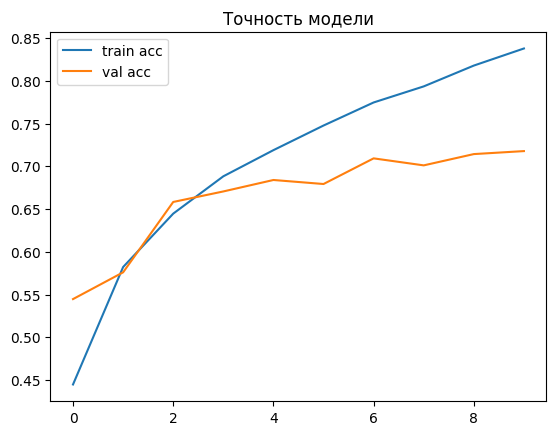

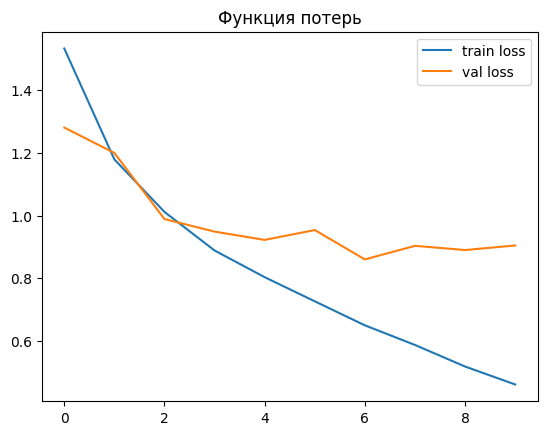

In [9]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Точность модели')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Функция потерь')
plt.legend()
plt.show()

## 7. Улучшение модели

> Наша сеть уже классифицирует, но можем повысить точность с помощью регуляризации.

**Техники улучшения:**

1. `Dropout` — “выключает” случайные нейроны, снижая переобучение.
2. `BatchNormalization` — стабилизирует обучение.
3. Увеличение данных (`ImageDataGenerator`) — искусственно расширяет тренировочный набор.

### Пример улучшенной модели:

In [10]:
from tensorflow.keras.layers import Dropout, BatchNormalization

model_improved = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    Dropout(0.3),

    layers.Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    layers.Flatten(),
    Dropout(0.3),

    layers.Dense(128, activation='relu'),
    BatchNormalization(),
    layers.Dense(10, activation='softmax')
])

model_improved.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_improved.fit(X_train, y_train, epochs=15, batch_size=64, validation_split=0.2, verbose=1)

/usr/lib/python3/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 49ms/step - accuracy: 0.4204 - loss: 1.6956 - val_accuracy: 0.5144 - val_loss: 1.3760
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.6224 - loss: 1.0679 - val_accuracy: 0.5107 - val_loss: 1.4340
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.6737 - loss: 0.9256 - val_accuracy: 0.5146 - val_loss: 1.4560
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.7090 - loss: 0.8244 - val_accuracy: 0.5597 - val_loss: 1.3540
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.7350 - loss: 0.7501 - val_accuracy: 0.6416 - val_loss: 1.0656
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.7528 - loss: 0.7009 - val_accuracy: 0.6959 - val_loss: 0.8883
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.7730 - loss: 0.6447 - val_accuracy: 0.7149 - val_loss: 0.8222
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.7818 - loss: 0.6172 - 

## 8. Анализ результатов

In [11]:
test_loss, test_acc = model_improved.evaluate(X_test, y_test)
print(f"Точность на тесте: {test_acc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7406 - loss: 0.8326
Точность на тесте: 0.740


### Визуализация ошибок:

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


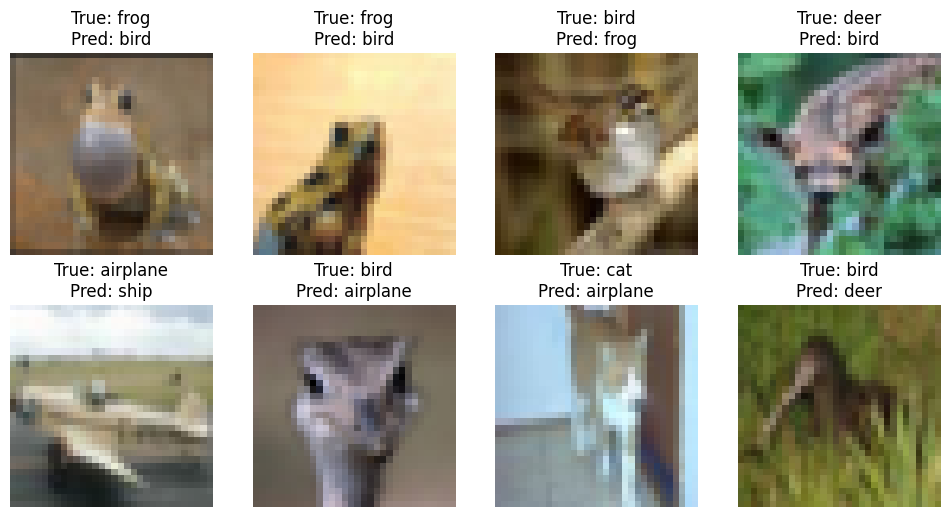

In [12]:
y_pred = np.argmax(model_improved.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

incorrect = np.where(y_pred != y_true)[0]
sample = np.random.choice(incorrect, 8, replace=False)

plt.figure(figsize=(12,6))
for i, idx in enumerate(sample):
    plt.subplot(2,4,i+1)
    plt.imshow(X_test[idx])
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis('off')
plt.show()

### Визуализация правильных результатов:

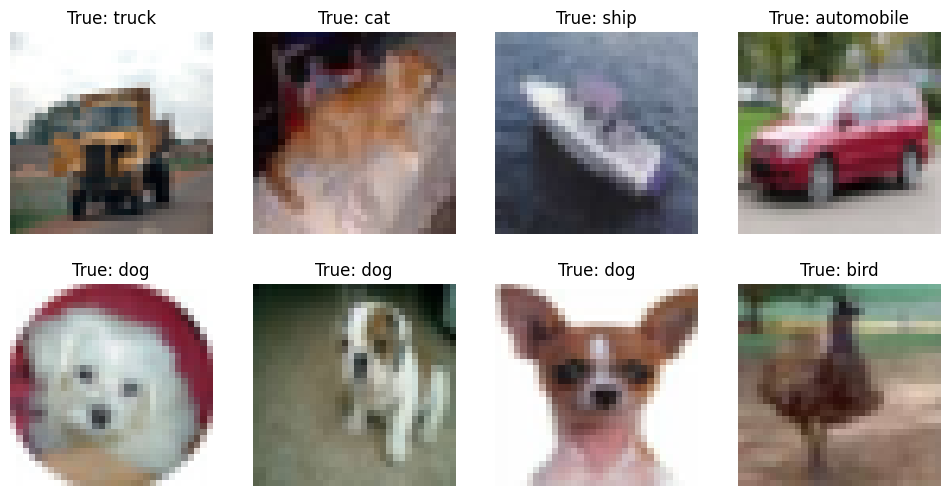

In [13]:
correct = np.where(y_pred == y_true)[0]
sample = np.random.choice(correct, 8, replace=False)

plt.figure(figsize=(12,6))
for i, idx in enumerate(sample):
    plt.subplot(2,4,i+1)
    plt.imshow(X_test[idx])
    plt.title(f"True: {class_names[y_true[idx]]}")
    plt.axis('off')
plt.show()

## 9. Визуализация фильтров (как “видит” CNN)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


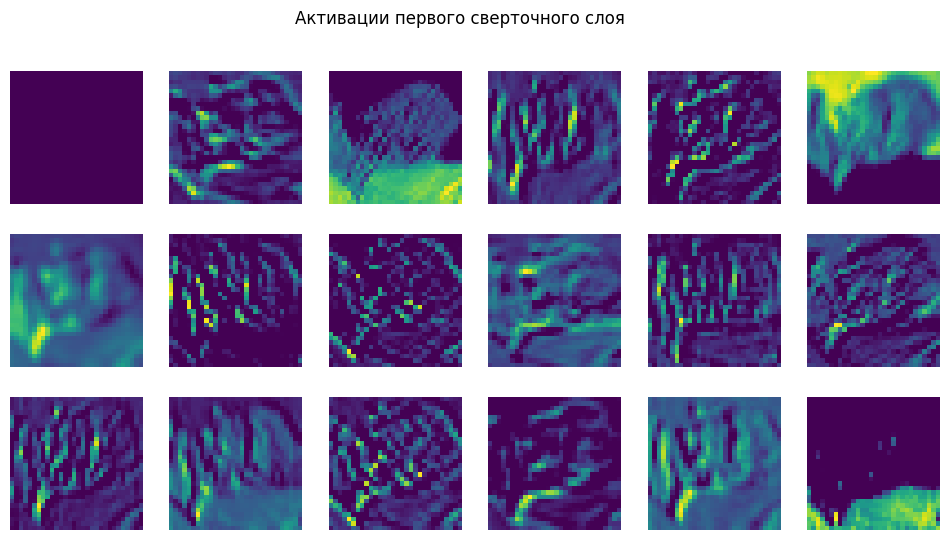

In [14]:
import matplotlib.pyplot as plt
from tensorflow.keras import Model, Input

# создаём новый вход и полностью пропускаем через старую модель слой за слоем
inp = Input(shape=(32, 32, 3))
x = inp
activations_list = []  # сюда будем собирать выходы слоёв

for layer in model_improved.layers:
    x = layer(x)
    if 'conv' in layer.name:
        activations_list.append(x)

# создаём модель, которая будет возвращать активации сверточных слоёв
visual_model = Model(inputs=inp, outputs=activations_list)

# прогоняем одно изображение
activations = visual_model.predict(X_test[:1])

# визуализируем первый сверточный слой
first_layer_activation = activations[0]

fig, axes = plt.subplots(3, 6, figsize=(12, 6))
for i, ax in enumerate(axes.flat[:first_layer_activation.shape[-1]]):
    ax.imshow(first_layer_activation[0, :, :, i], cmap='viridis')
    ax.axis('off')

plt.suptitle("Активации первого сверточного слоя")
plt.show()

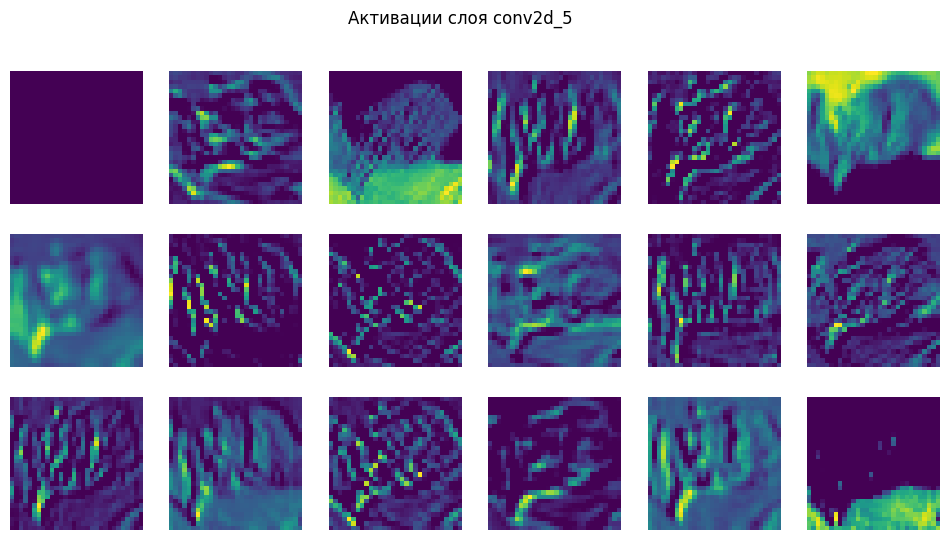

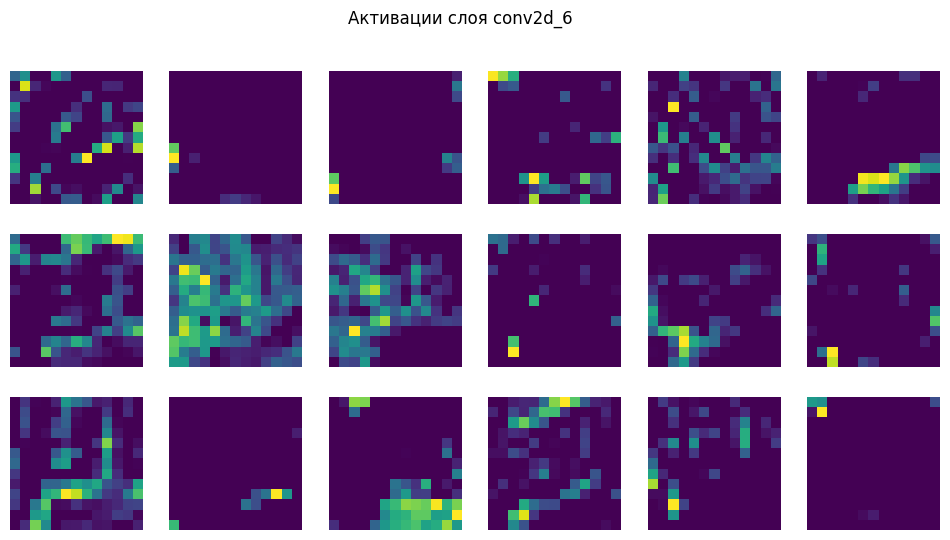

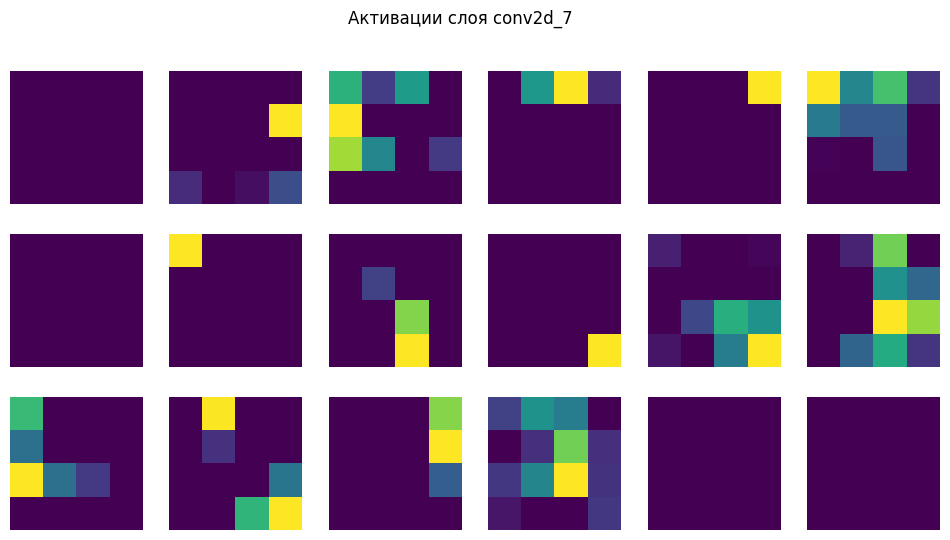

In [15]:
layer_names = [layer.name for layer in model_improved.layers if 'conv' in layer.name]

for layer_name, layer_activation in zip(layer_names[:3], activations[:3]):
    fig, axes = plt.subplots(3, 6, figsize=(12, 6))
    for i, ax in enumerate(axes.flat[:layer_activation.shape[-1]]):
        ax.imshow(layer_activation[0, :, :, i], cmap='viridis')
        ax.axis('off')
    plt.suptitle(f"Активации слоя {layer_name}")
    plt.show()

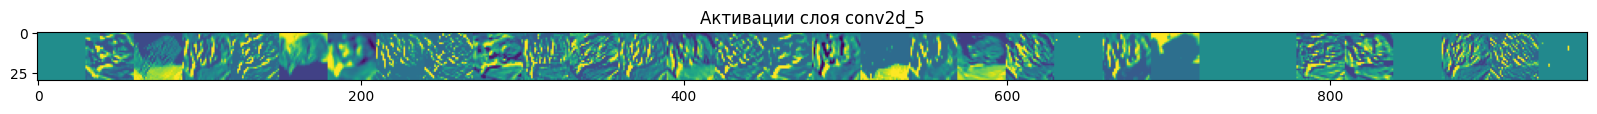

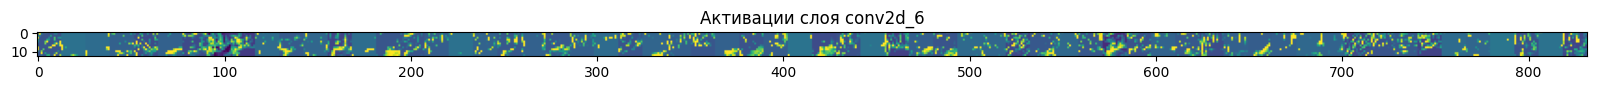

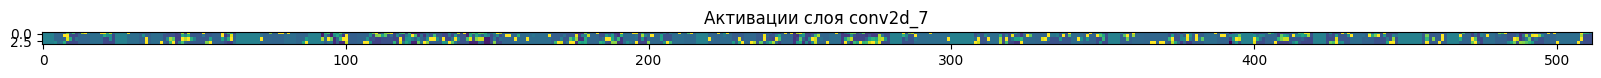

In [16]:
layer_names = [layer.name for layer in model_improved.layers if 'conv' in layer.name]

for layer_name, layer_activation in zip(layer_names, activations):
    n_features = layer_activation.shape[-1]
    size = layer_activation.shape[1]

    display_grid = np.zeros((size, n_features * size))

    for i in range(n_features):
        feature_map = layer_activation[0, :, :, i]
        feature_map -= feature_map.mean()
        feature_map /= (feature_map.std() + 1e-5)
        feature_map *= 64
        feature_map += 128
        feature_map = np.clip(feature_map, 0, 255).astype('uint8')
        display_grid[:, i * size : (i + 1) * size] = feature_map

    scale = 20. / n_features
    plt.figure(figsize=(scale * n_features, scale))
    plt.title(f"Активации слоя {layer_name}")
    plt.grid(False)
    plt.imshow(display_grid, aspect='auto', cmap='viridis')
    plt.show()


## Вопросы:

* Почему CNN работают лучше, чем Dense для изображений?
* Что делает MaxPooling и зачем он нужен?
* Что происходит внутри фильтров CNN?
* Почему dropout помогает бороться с переобучением?

## Домашнее задание

### Задание 1

Измени архитектуру сети:

* Добавь/удали один `Conv2D` слой
* Измени размер фильтра (например, (5,5))
* Сравни точность

### Задание 2

Попробуй изменить `optimizer` (`SGD`, `RMSprop`) и количество эпох.
Сделай вывод: как влияет оптимизатор и время обучения на результат?

### Задание 3

Визуализируй ошибки:

* Найди, какие классы чаще всего путаются.
* Нарисуй `confusion_matrix` для тестовых данных.